# A1b: Counter-UAS Glider Infiltration — Simulation & Results

This notebook produces the research results for the Stackelberg Security Game
formulation of the counter-UAS glider detection evasion problem.

**Structure:**
1. Imports and setup
2. Sensor calibration
3. Calibration verification
4. Attacker best response (single solve)
5. Stackelberg equilibrium (defender grid search)
6. Equilibrium trajectory visualization
7. Strategy comparison
8. Sensitivity analysis

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath('/home/jeff/git/ros2_ws/src/glider_hybrid_control'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from environment.geometry import Geometry
from environment.vehicle import Vehicle, VehicleParams, AirframeParams
from environment.sensors import (SensorSuite, AcousticSensor, DopplerSensor, RCSSensor, CameraSensor,
                                 AcousticParams, DopplerParams, RCSParams, CameraParams)
from environment.game import Game, AttackerWeights, DefenderWeights

print('My lord, we have completed the ritual of importation.')

My lord, we have completed the ritual of importation.


---
## Section 1 — Sensor Calibration

Before any game-theoretic analysis, we must calibrate the four sensor
sensitivity constants (kappa values) so that all sensors contribute
comparable pod rates along a typical trajectory.

**Why this matters:** If one sensor dominates by orders of magnitude,
the attacker's optimization effectively ignores the other sensors.
The three-way acoustic-Doppler-RCS contradiction we designed the problem
around will not manifest in the cost function.

**Calibration approach:** We choose a reference state along a typical
approach trajectory and scale each kappa so all sensors produce
pod rates of the same order of magnitude at that reference point.

In [2]:
# ── Clean sensor calibration ────────────────────────────────────────────────
# Design criterion: each sensor contributes a hazard integral of ~0.3-0.5
# over a typical reference trajectory. This gives total J_PD ~ 0.7-0.9,
# leaving room for the attacker to improve through trajectory optimization.
#
# Approach: simulate reference trajectory, measure raw integral per sensor,
# then set kappa so each sensor's integral = target_integral.

target_integral_per_sensor = 0.4   # each sensor contributes ~0.4 to total integral
                                    # total ~ 1.6, J_PD ~ 1 - exp(-1.6) ~ 0.8

# Reference trajectory
h_dot_cal = 3.0
vp_cal    = VehicleParams()
LD_cal    = np.sqrt(vp_cal.airframe.C_D0 / vp_cal.airframe.k) / (2 * vp_cal.airframe.C_D0)
v_c_cal   = vp_cal.v_climb
h_sw_cal  = ((vp_cal.z_goal - vp_cal.z_start) / (LD_cal + v_c_cal / h_dot_cal)) * 1.5
z_d_cal   = (vp_cal.z_start + vp_cal.z_goal) / 2.0   # sensor at midpoint
gamma_cal = -0.10   # shallow glide — most exposure to sensors

vehicle_cal = Vehicle(vp_cal)
traj_cal    = vehicle_cal.simulate(h_dot_cal, h_sw_cal, gamma_cal)
arr_cal     = vehicle_cal.to_arrays(traj_cal)
geom_cal    = Geometry(z_d=z_d_cal)

# Compute raw integral for each sensor with kappa = 1.0
ac_raw   = AcousticSensor(AcousticParams(kappa=1.0))
dopp_raw = DopplerSensor(DopplerParams(kappa=1.0))
rcs_raw  = RCSSensor(RCSParams(kappa=1.0))
cam_raw  = CameraSensor(CameraParams(kappa=1.0))

def integrate_sensor(sensor, traj, geom):
    rates = []
    for p in traj:
        rates.append(sensor.pod_rate(p.z, p.h, p.v, p.gamma, geom, p.phase))
    rates = np.array(rates)
    dt    = np.diff(arr_cal['t'])
    return np.sum(0.5 * (rates[:-1] + rates[1:]) * dt)

integral_ac   = integrate_sensor(ac_raw,   traj_cal, geom_cal)
integral_dopp = integrate_sensor(dopp_raw, traj_cal, geom_cal)
integral_rcs  = integrate_sensor(rcs_raw,  traj_cal, geom_cal)
integral_cam  = integrate_sensor(cam_raw,  traj_cal, geom_cal)

print(f"Raw integrals (kappa=1.0) over reference trajectory:")
print(f"  acoustic : {integral_ac:.4e}")
print(f"  doppler  : {integral_dopp:.4e}")
print(f"  rcs      : {integral_rcs:.4e}")
print(f"  camera   : {integral_cam:.4e}")

# kappa = target_integral / raw_integral
kappa_ac_cal   = target_integral_per_sensor / integral_ac   if integral_ac   > 0 else 1e-4
kappa_dopp_cal = target_integral_per_sensor / integral_dopp if integral_dopp > 0 else 1e-6
kappa_rcs_cal  = target_integral_per_sensor / integral_rcs  if integral_rcs  > 0 else 1e-6
kappa_cam_cal  = target_integral_per_sensor / integral_cam  if integral_cam  > 0 else 5e-5

print(f"\nCalibrated kappas (each sensor integral = {target_integral_per_sensor}):")
print(f"  kappa_acoustic : {kappa_ac_cal:.4e}")
print(f"  kappa_doppler  : {kappa_dopp_cal:.4e}")
print(f"  kappa_rcs      : {kappa_rcs_cal:.4e}")
print(f"  kappa_camera   : {kappa_cam_cal:.4e}")

# Build game with calibrated sensors
game = Game(
    acoustic_params=AcousticParams(kappa=kappa_ac_cal),
    doppler_params=DopplerParams(kappa=kappa_dopp_cal),
    rcs_params=RCSParams(kappa=kappa_rcs_cal),
    camera_params=CameraParams(kappa=kappa_cam_cal),
)

# Verify
result_verify = game.evaluate(h_dot_cal, h_sw_cal, gamma_cal, z_d_cal)
print(f"\nVerification on reference trajectory:")
print(f"  J_PD = {result_verify['J_PD']:.4f}  (target ~0.80)")
print(f"  J_A  = {result_verify['J_A']:.4f}")

Raw integrals (kappa=1.0) over reference trajectory:
  acoustic : 6.8450e+03
  doppler  : 5.7678e-10
  rcs      : 5.2411e-13
  camera   : 1.7125e-05

Calibrated kappas (each sensor integral = 0.4):
  kappa_acoustic : 5.8437e-05
  kappa_doppler  : 6.9351e+08
  kappa_rcs      : 7.6320e+11
  kappa_camera   : 2.3358e+04

Verification on reference trajectory:
  J_PD = 0.7981  (target ~0.80)
  J_A  = 0.7758


---
## Section 2 — Calibration Verification

We verify that all four sensors contribute meaningfully along a full
trajectory, and that the three-way contradiction is active —
meaning no single gamma minimizes all sensor pod rates simultaneously.

In [3]:
# ── Shared feasible trajectory parameters ──────────────────────────────────
# Computed once here and reused by all subsequent cells.
# Never hardcode h_sw anywhere else in this notebook.

def min_feasible_h_sw(vehicle, h_dot):
    """Minimum h_sw such that Delta >= 0 for given h_dot."""
    LD  = vehicle.LD_max
    v_c = vehicle.p.v_climb
    return (vehicle.p.z_goal - vehicle.p.z_start) / (LD + v_c / h_dot)

# Reference trajectory (used for calibration verification)
H_DOT_REF   = 3.0
H_SW_REF    = min_feasible_h_sw(game.vehicle, H_DOT_REF) * 1.5

# Naive strategy
H_DOT_NAIVE = game.vp.h_dot_max
H_SW_NAIVE  = min_feasible_h_sw(game.vehicle, H_DOT_NAIVE) * 1.3
GAMMA_NAIVE = np.radians(-15.0)

# Steep dive strategy
H_DOT_STEEP = game.vp.h_dot_max
H_SW_STEEP  = min_feasible_h_sw(game.vehicle, H_DOT_STEEP) * 1.2
GAMMA_STEEP = np.radians(-35.0)

# Dive-bombing strategy
H_DOT_DIVE  = game.vp.h_dot_max
H_SW_DIVE   = min_feasible_h_sw(game.vehicle, H_DOT_DIVE) * 1.1
GAMMA_SHALLOW_DIVE = game.vp.gamma_max
GAMMA_TERMINAL_DIVE = np.radians(-75.0)

print("Shared feasible parameters:")
print(f"  H_SW_REF   = {H_SW_REF:.1f} m  (h_dot={H_DOT_REF})")
print(f"  H_SW_NAIVE = {H_SW_NAIVE:.1f} m  (h_dot={H_DOT_NAIVE})")
print(f"  H_SW_STEEP = {H_SW_STEEP:.1f} m  (h_dot={H_DOT_STEEP})")
print(f"  H_SW_DIVE  = {H_SW_DIVE:.1f} m   (h_dot={H_DOT_DIVE})")

Shared feasible parameters:
  H_SW_REF   = 3227.1 m  (h_dot=3.0)
  H_SW_NAIVE = 3265.2 m  (h_dot=5.0)
  H_SW_STEEP = 3014.0 m  (h_dot=5.0)
  H_SW_DIVE  = 2762.8 m   (h_dot=5.0)


Reference trajectory: h_dot=3.0, h_sw=3227.1m, z_sw=26892.8m, delta=25000.0m


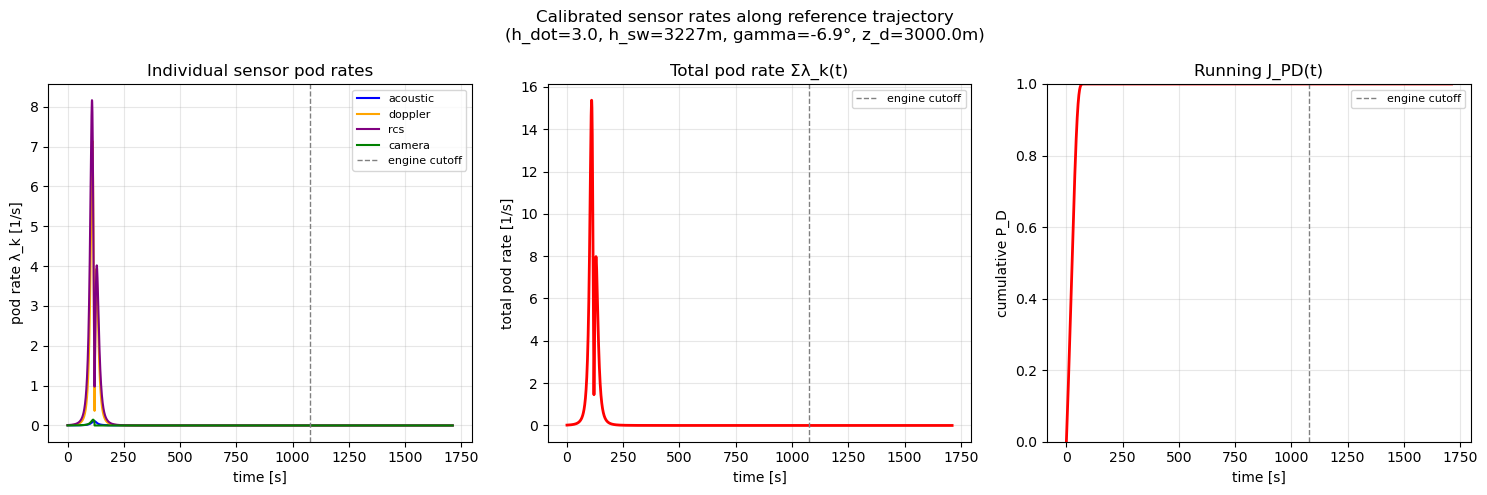

Final J_PD = 1.0000
Sensor contributions at engine cutoff (t=1076.0s):
  acoustic    : integral = 4.7672
  doppler     : integral = 200.6803
  rcs         : integral = 254.7777
  camera      : integral = 3.3132


In [4]:
# Use shared feasible parameters computed at notebook top
h_dot_ref      = H_DOT_REF
h_sw_ref       = H_SW_REF
gamma_ref_traj = -0.12
z_d_viz        = 3000.0

# Verify
t_c     = h_sw_ref / h_dot_ref
z_sw_c  = game.vp.z_start + game.vp.v_climb * t_c
delta_c = game.vehicle.compute_delta(z_sw_c, h_sw_ref)
print(f"Reference trajectory: h_dot={h_dot_ref}, h_sw={h_sw_ref:.1f}m, "
      f"z_sw={z_sw_c:.1f}m, delta={delta_c:.1f}m")
# Simulate
traj_ref   = game.vehicle.simulate(h_dot_ref, h_sw_ref, gamma_ref_traj)
arr_ref    = game.vehicle.to_arrays(traj_ref)
rates      = game.get_individual_pod_arrays(traj_ref, z_d=z_d_viz)
cutoff_idx = np.argmax(arr_ref["phase"] == 2)
cutoff_t   = arr_ref["t"][cutoff_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"Calibrated sensor rates along reference trajectory\n"
    f"(h_dot={h_dot_ref}, h_sw={h_sw_ref:.0f}m, "
    f"gamma={np.degrees(gamma_ref_traj):.1f}°, z_d={z_d_viz}m)",
    fontsize=12
)

# Individual pod rates
for sensor, color in [("acoustic","blue"), ("doppler","orange"),
                       ("rcs","purple"),   ("camera","green")]:
    axes[0].plot(arr_ref["t"], rates[sensor],
                 label=sensor, color=color, linewidth=1.5)
axes[0].axvline(cutoff_t, color="gray", linestyle="--",
                linewidth=1, label="engine cutoff")
axes[0].set_xlabel("time [s]")
axes[0].set_ylabel("pod rate λ_k [1/s]")
axes[0].set_title("Individual sensor pod rates")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Total pod rate
total_rate = sum(rates[k] for k in rates)
axes[1].plot(arr_ref["t"], total_rate, color="red", linewidth=2)
axes[1].axvline(cutoff_t, color="gray", linestyle="--",
                linewidth=1, label="engine cutoff")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("total pod rate [1/s]")
axes[1].set_title("Total pod rate Σλ_k(t)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Running J_PD
dt_ref  = np.diff(arr_ref["t"])
cumint  = np.concatenate([[0],
           np.cumsum(0.5*(total_rate[:-1]+total_rate[1:])*dt_ref)])
jpd_run = 1.0 - np.exp(-cumint)

axes[2].plot(arr_ref["t"], jpd_run, color="red", linewidth=2)
axes[2].axvline(cutoff_t, color="gray", linestyle="--",
                linewidth=1, label="engine cutoff")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("cumulative P_D")
axes[2].set_title("Running J_PD(t)")
axes[2].set_ylim([0, 1])
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Final J_PD = {jpd_run[-1]:.4f}")
print(f"Sensor contributions at engine cutoff (t={cutoff_t:.1f}s):")
for k in rates:
    contrib = np.trapz(rates[k][:cutoff_idx+1], arr_ref["t"][:cutoff_idx+1])
    print(f"  {k:12s}: integral = {contrib:.4f}")

Sweep parameters: h_dot=3.0, h_sw=3227.1m, z_d=25000.0m


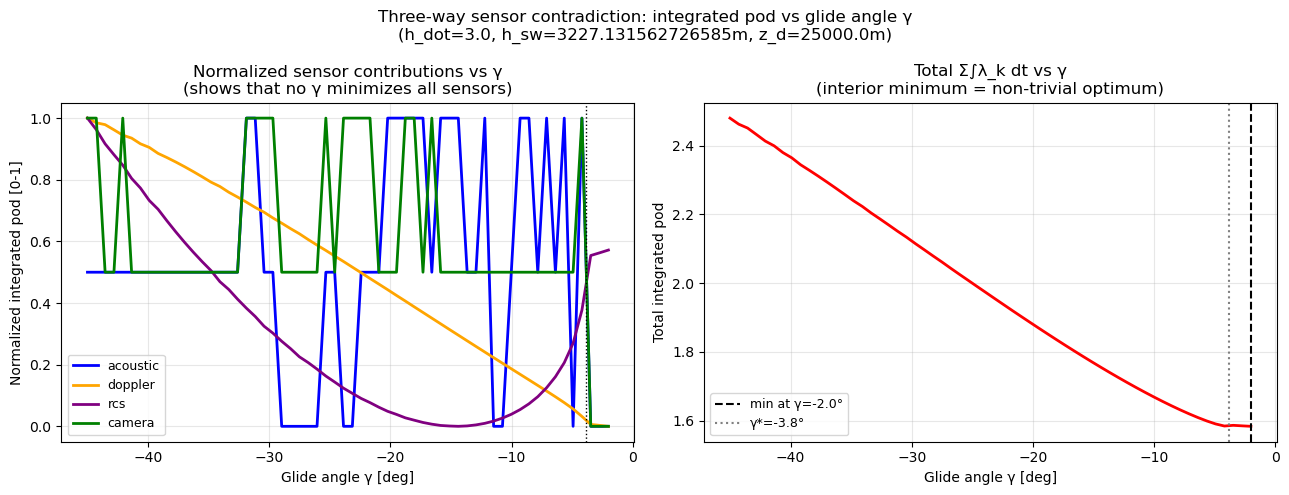

Gamma that minimizes total pod: -2.01 deg
Best glide angle gamma*:           -3.84 deg
They differ: True


In [5]:
# Sweep gamma across the full range and plot how each sensor's
# integrated pod rate responds.
# This directly shows the three-way contradiction:
# no single gamma minimizes all sensors simultaneously.

# gamma_sweep = np.linspace(game.vp.gamma_min, game.vp.gamma_max, 60)
# Sweep gamma across the full range and plot how each sensor's
# integrated pod rate responds.

# # Compute feasible h_sw for the sweep
# h_dot_sw = 3.0
# LD       = game.vehicle.LD_max
# v_c      = game.vp.v_climb

# h_sw_min_sw = (game.vp.z_goal - game.vp.z_start) / (LD + v_c / h_dot_sw)
# h_sw_sw     = float(h_sw_min_sw * 1.5)
# h_sw_sw     = float(np.clip(h_sw_sw, 50.0, 1500.0))

# z_d_sw = 3000.0

# # Verify
# t_c_sw    = h_sw_sw / h_dot_sw
# z_sw_sw   = game.vp.z_start + v_c * t_c_sw
# delta_sw  = game.vehicle.compute_delta(z_sw_sw, h_sw_sw)
# print(f"Sweep parameters: h_dot={h_dot_sw}, h_sw={h_sw_sw:.1f}m, "
#       f"z_sw={z_sw_sw:.1f}m, delta={delta_sw:.1f}m")

# gamma_sweep = np.linspace(game.vp.gamma_min, game.vp.gamma_max, 60)
# integrals   = {"acoustic": [], "doppler": [], "rcs": [], "camera": [], "total": []}

# Use shared feasible parameters
h_dot_sw = H_DOT_REF
h_sw_sw  = H_SW_REF
z_d_sw   = 25000.0

print(f"Sweep parameters: h_dot={h_dot_sw}, h_sw={h_sw_sw:.1f}m, z_d={z_d_sw}m")

gamma_sweep = np.linspace(game.vp.gamma_min, game.vp.gamma_max, 60)
integrals   = {"acoustic": [], "doppler": [], "rcs": [], "camera": [], "total": []}

for g in gamma_sweep:
    try:
        traj_g  = game.vehicle.simulate(h_dot_sw, h_sw_sw, g)
        rates_g = game.get_individual_pod_arrays(traj_g, z_d=z_d_sw)
        arr_g   = game.vehicle.to_arrays(traj_g)
        dt_g    = np.diff(arr_g["t"])

        for k in ["acoustic", "doppler", "rcs", "camera"]:
            integrals[k].append(
                np.sum(0.5*(rates_g[k][:-1]+rates_g[k][1:])*dt_g)
            )
        total_g = sum(rates_g[k] for k in ["acoustic","doppler","rcs","camera"])
        integrals["total"].append(
            np.sum(0.5*(total_g[:-1]+total_g[1:])*dt_g)
        )
    except Exception:
        for k in integrals:
            integrals[k].append(np.nan)

gamma_deg = np.degrees(gamma_sweep)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(
    "Three-way sensor contradiction: integrated pod vs glide angle γ\n"
    f"(h_dot={h_dot_sw}, h_sw={h_sw_sw}m, z_d={z_d_sw}m)",
    fontsize=12
)

# Individual sensor integrals
for k, color in [("acoustic","blue"), ("doppler","orange"),
                  ("rcs","purple"),   ("camera","green")]:
    vals = np.array(integrals[k])
    # Normalize each to [0,1] for visual comparison
    v_min, v_max = np.nanmin(vals), np.nanmax(vals)
    if v_max > v_min:
        vals_norm = (vals - v_min) / (v_max - v_min)
    else:
        vals_norm = vals
    axes[0].plot(gamma_deg, vals_norm,
                 label=k, color=color, linewidth=2)

axes[0].set_xlabel("Glide angle γ [deg]")
axes[0].set_ylabel("Normalized integrated pod [0-1]")
axes[0].set_title("Normalized sensor contributions vs γ\n"
                   "(shows that no γ minimizes all sensors)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].axvline(np.degrees(game.vehicle.gamma_star), color="black",
                linestyle=":", linewidth=1, label="γ*")

# Total integrated pod → shows interior optimum
total_arr = np.array(integrals["total"])
axes[1].plot(gamma_deg, total_arr, color="red", linewidth=2)
best_idx  = np.nanargmin(total_arr)
axes[1].axvline(gamma_deg[best_idx], color="black", linestyle="--",
                label=f"min at γ={gamma_deg[best_idx]:.1f}°")
axes[1].axvline(np.degrees(game.vehicle.gamma_star), color="gray",
                linestyle=":", label=f"γ*={np.degrees(game.vehicle.gamma_star):.1f}°")
axes[1].set_xlabel("Glide angle γ [deg]")
axes[1].set_ylabel("Total integrated pod")
axes[1].set_title("Total Σ∫λ_k dt vs γ\n(interior minimum = non-trivial optimum)")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Gamma that minimizes total pod: {gamma_deg[best_idx]:.2f} deg")
print(f"Best glide angle gamma*:           {np.degrees(game.vehicle.gamma_star):.2f} deg")
print(f"They differ: {abs(gamma_deg[best_idx] - np.degrees(game.vehicle.gamma_star)) > 0.5}")

---
## Section 4 — Stackelberg Equilibrium

Solve the full backward induction:

**Step 1 (inner):** For each candidate z_d, find the attacker's best response:
    a*(z_d) = argmin_a J_A(a, z_d)

**Step 2 (outer):** Find the defender's optimal placement:
    z_d* = argmax_{z_d} J_D(z_d, a*(z_d))

The pair (z_d*, a*(z_d*)) is the Strong Stackelberg Equilibrium.

Source: Tambe, M. (2011). Security and Game Theory: Algorithms,
Deployed Systems, Lessons Learned. Cambridge University Press. Chapter 2.

In [6]:
print("Running Stackelberg equilibrium computation...")
print("(Grid search: n_grid=30, each point runs Nelder-Mead)\n")

stackelberg = game.defender_best_response(n_grid=40, verbose=True)

print(f"\n{'='*50}")
print(f"STACKELBERG EQUILIBRIUM")
print(f"{'='*50}")
print(f"  z_d*  = {stackelberg['z_d_star']:.0f} m  (optimal sensor placement)")
print(f"  J_D*  = {stackelberg['J_D_star']:.4f}     (defender utility at equilibrium)")

best_br = stackelberg["best"]["attacker_response"]
print(f"\n  Attacker best response at z_d*:")
print(f"    h_dot  = {best_br['h_dot']:.3f} m/s")
print(f"    h_sw   = {best_br['h_sw']:.1f} m")
print(f"    z_sw   = {best_br['z_sw']:.1f} m")
print(f"    gamma  = {np.degrees(best_br['gamma']):.2f} deg")
print(f"    J_A    = {best_br['J_A']:.4f}")
print(f"    J_PD   = {best_br['J_PD']:.4f}")

Running Stackelberg equilibrium computation...
(Grid search: n_grid=30, each point runs Nelder-Mead)

[1/40] z_d = 2500... 

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


ValueError: Infeasible: Delta=-47784.6 m,Cannot reach z_goal from (z_sw=879.0 m, h_sw=89.7 m)Increase h_sw or reduce h_dot

In [ ]:
z_d_fixed = stackelberg['z_d_star']

print(f"Solving attacker best response for z_d = {z_d_fixed} m...")
print("(Nelder-Mead, may take ~30 seconds)\n")

# 1 continuous
# br = game.attacker_best_response(z_d=z_d_fixed, verbose=False)
# piecewise gamma optimizer
br = game.attacker_best_response_piecewise(
    z_d = stackelberg['z_d_star'], N=10, verbose=False
)
# print(len(br['full_result']['trajectory']))

print("Optimal attacker decisions:")
print(f"  h_dot  = {br['h_dot']:.3f} m/s  (climb rate)")
print(f"  h_sw   = {br['h_sw']:.1f} m      (engine cutoff altitude)")
print(f"  z_sw   = {br['z_sw']:.1f} m      (engine cutoff position)")
# print(f"  gamma  = {np.degrees(br['gamma']):.2f} deg  (glide angle)")
print(f"  delta  = {br['delta']:.1f} m      (range budget)")
print(f"\nCosts:")
print(f"  J_PD   = {br['J_PD']:.4f}  (detection probability)")
print(f"  J_A    = {br['J_A']:.4f}  (attacker total cost)")
print(f"  T      = {br['T']:.1f} s    (flight time)")
print(f"\nOptimizer:")
print(f"  success = {br['success']}")
print(f"  n_evals = {br['n_evals']}")

Solving attacker best response for z_d = 23269.23076923077 m...
(Nelder-Mead, may take ~30 seconds)

Optimal attacker decisions:
  h_dot  = 2.550 m/s  (climb rate)
  h_sw   = 1702.1 m      (engine cutoff altitude)
  z_sw   = 20829.0 m      (engine cutoff position)
  delta  = -3798.3 m      (range budget)

Costs:
  J_PD   = 0.9945  (detection probability)
  J_A    = 0.9499  (attacker total cost)
  T      = 2089.7 s    (flight time)

Optimizer:
  success = True
  n_evals = 293


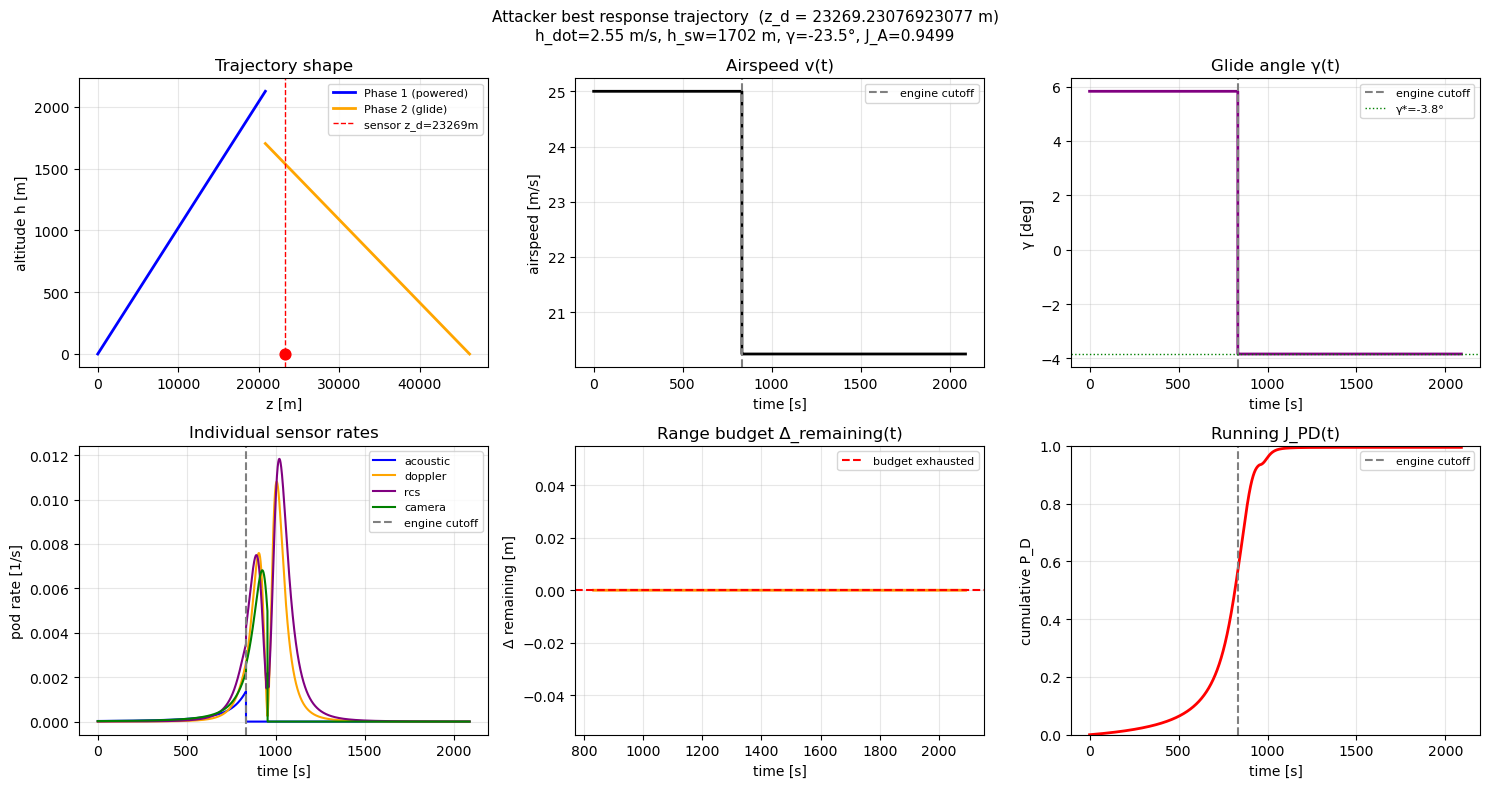

In [ ]:
traj_br = br["full_result"]["trajectory"]
arr_br  = game.vehicle.to_arrays(traj_br)
rates_br = game.get_individual_pod_arrays(traj_br, z_d=z_d_fixed)

cutoff_idx_br = np.argmax(arr_br["phase"] == 2)
cutoff_t_br   = arr_br["t"][cutoff_idx_br]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    f"Attacker best response trajectory  (z_d = {z_d_fixed} m)\n"
    f"h_dot={br['h_dot']:.2f} m/s, "
    f"h_sw={br['h_sw']:.0f} m, "
    f"γ={np.degrees(np.mean(br['gamma'])):.1f}°, "
    f"J_A={br['J_A']:.4f}",
    fontsize=11
)

phase1_m = arr_br["phase"] == 1
phase2_m = arr_br["phase"] == 2

# Trajectory
axes[0,0].plot(arr_br["z"][phase1_m], arr_br["h"][phase1_m],
               color="blue", linewidth=2, label="Phase 1 (powered)")
axes[0,0].plot(arr_br["z"][phase2_m], arr_br["h"][phase2_m],
               color="orange", linewidth=2, label="Phase 2 (glide)")
axes[0,0].axvline(z_d_fixed, color="red", linestyle="--",
                  linewidth=1, label=f"sensor z_d={z_d_fixed:.0f}m")
axes[0,0].scatter([z_d_fixed], [0], color="red", zorder=5, s=60)
axes[0,0].set_xlabel("z [m]")
axes[0,0].set_ylabel("altitude h [m]")
axes[0,0].set_title("Trajectory shape")
axes[0,0].legend(fontsize=8)
axes[0,0].grid(True, alpha=0.3)

# Airspeed
axes[0,1].plot(arr_br["t"], arr_br["v"], color="black", linewidth=2)
axes[0,1].axvline(cutoff_t_br, color="gray", linestyle="--",
                  label="engine cutoff")
axes[0,1].set_xlabel("time [s]")
axes[0,1].set_ylabel("airspeed [m/s]")
axes[0,1].set_title("Airspeed v(t)")
axes[0,1].legend(fontsize=8)
axes[0,1].grid(True, alpha=0.3)

# Glide angle
axes[0,2].plot(arr_br["t"], np.degrees(arr_br["gamma"]),
               color="purple", linewidth=2)
axes[0,2].axvline(cutoff_t_br, color="gray", linestyle="--",
                  label="engine cutoff")
axes[0,2].axhline(np.degrees(game.vehicle.gamma_star),
                  color="green", linestyle=":", linewidth=1,
                  label=f"γ*={np.degrees(game.vehicle.gamma_star):.1f}°")
axes[0,2].set_xlabel("time [s]")
axes[0,2].set_ylabel("γ [deg]")
axes[0,2].set_title("Glide angle γ(t)")
axes[0,2].legend(fontsize=8)
axes[0,2].grid(True, alpha=0.3)

# Individual sensor rates
for k, color in [("acoustic","blue"), ("doppler","orange"),
                  ("rcs","purple"),   ("camera","green")]:
    axes[1,0].plot(arr_br["t"], rates_br[k],
                   label=k, color=color, linewidth=1.5)
axes[1,0].axvline(cutoff_t_br, color="gray", linestyle="--",
                  label="engine cutoff")
axes[1,0].set_xlabel("time [s]")
axes[1,0].set_ylabel("pod rate [1/s]")
axes[1,0].set_title("Individual sensor rates")
axes[1,0].legend(fontsize=8)
axes[1,0].grid(True, alpha=0.3)

# Delta remaining
axes[1,1].plot(arr_br["t"][phase2_m],
               arr_br["delta_remaining"][phase2_m],
               color="darkorange", linewidth=2)
axes[1,1].axhline(0, color="red", linestyle="--", label="budget exhausted")
axes[1,1].set_xlabel("time [s]")
axes[1,1].set_ylabel("Δ remaining [m]")
axes[1,1].set_title("Range budget Δ_remaining(t)")
axes[1,1].legend(fontsize=8)
axes[1,1].grid(True, alpha=0.3)

# Running J_PD
total_rate_br = sum(rates_br[k] for k in rates_br)
dt_br = np.diff(arr_br["t"])
cumint_br = np.concatenate([[0],
             np.cumsum(0.5*(total_rate_br[:-1]+total_rate_br[1:])*dt_br)])
jpd_run_br = 1.0 - np.exp(-cumint_br)

axes[1,2].plot(arr_br["t"], jpd_run_br, color="red", linewidth=2)
axes[1,2].axvline(cutoff_t_br, color="gray", linestyle="--",
                  label="engine cutoff")
axes[1,2].set_xlabel("time [s]")
axes[1,2].set_ylabel("cumulative P_D")
axes[1,2].set_title("Running J_PD(t)")
axes[1,2].set_ylim([0, 1])
axes[1,2].legend(fontsize=8)
axes[1,2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Check if sensors are creating spatial variation incentive
traj_pw  = br["full_result"]["trajectory"]
arr_pw   = game.vehicle.to_arrays(traj_pw)
rates_pw = game.get_individual_pod_arrays(traj_pw, z_d=z_d_fixed)

glide_mask = arr_pw["phase"] == 2
print("\nGlide phase sensor contributions:")
print(len(rates_pw))
for k in rates_pw:
    glide_integral = np.trapz(
        rates_pw[k][glide_mask],
        arr_pw["t"][glide_mask]
    )
    print(f"  {k:12s}: {glide_integral:.4f}")


Glide phase sensor contributions:
4
  acoustic    : 0.0000
  doppler     : 1.6489
  rcs         : 2.0933
  camera      : 0.6140


In [ ]:
print("Piecewise gammas (N=10):")
for i, g in enumerate(br['gamma']):
    print(f"  segment {i+1}: {np.degrees(g):.4f} deg")

print(f"\nAll equal? {np.allclose(br['gamma'], br['gamma'][0])}")
print(f"Std dev:   {np.degrees(np.std(br['gamma'])):.6f} deg")

Piecewise gammas (N=10):
  segment 1: -23.5027 deg
  segment 2: -23.5027 deg
  segment 3: -23.5027 deg
  segment 4: -23.5027 deg
  segment 5: -23.5027 deg
  segment 6: -23.5027 deg
  segment 7: -23.5027 deg
  segment 8: -23.5027 deg
  segment 9: -23.5027 deg
  segment 10: -23.5027 deg

All equal? True
Std dev:   0.000000 deg


In [ ]:
glide_mask  = arr_pw["phase"] == 2
power_mask  = arr_pw["phase"] == 1

print("Glide phase sensor integrals:")
for k in rates_pw:
    integral = np.trapz(rates_pw[k][glide_mask], arr_pw["t"][glide_mask])
    print(f"  {k:12s}: {integral:.6f}")

print(f"\nPowered phase integrals:")
for k in rates_pw:
    integral = np.trapz(rates_pw[k][power_mask], arr_pw["t"][power_mask])
    print(f"  {k:12s}: {integral:.6f}")

Glide phase sensor integrals:
  acoustic    : 0.000000
  doppler     : 1.648856
  rcs         : 2.093313
  camera      : 0.614031

Powered phase integrals:
  acoustic    : 0.172365
  doppler     : 0.172851
  rcs         : 0.266824
  camera      : 0.225864


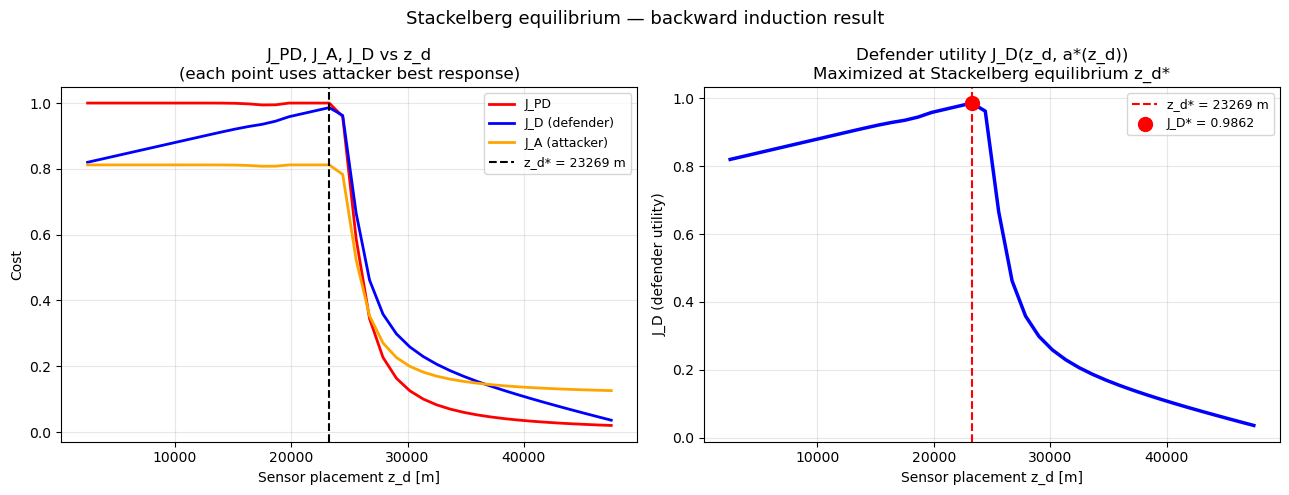

In [ ]:
all_r    = stackelberg["all_results"]
z_d_arr  = np.array([r["z_d"]  for r in all_r])
J_D_arr  = np.array([r["J_D"]  for r in all_r])
J_A_arr  = np.array([r["J_A"]  for r in all_r])
J_PD_arr = np.array([r["J_PD"] for r in all_r])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Stackelberg equilibrium — backward induction result", fontsize=13)

# Left: all three costs vs z_d
axes[0].plot(z_d_arr, J_PD_arr, color="red",    linewidth=2, label="J_PD")
axes[0].plot(z_d_arr, J_D_arr,  color="blue",   linewidth=2, label="J_D (defender)")
axes[0].plot(z_d_arr, J_A_arr,  color="orange", linewidth=2, label="J_A (attacker)")
axes[0].axvline(stackelberg["z_d_star"], color="black",
                linestyle="--", linewidth=1.5,
                label=f"z_d* = {stackelberg['z_d_star']:.0f} m")
axes[0].set_xlabel("Sensor placement z_d [m]")
axes[0].set_ylabel("Cost")
axes[0].set_title("J_PD, J_A, J_D vs z_d\n(each point uses attacker best response)")
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Right: J_D only, highlight optimum
axes[1].plot(z_d_arr, J_D_arr, color="blue", linewidth=2.5)
axes[1].axvline(stackelberg["z_d_star"], color="red",
                linestyle="--", linewidth=1.5,
                label=f"z_d* = {stackelberg['z_d_star']:.0f} m")
axes[1].scatter([stackelberg["z_d_star"]], [stackelberg["J_D_star"]],
                color="red", zorder=5, s=100,
                label=f"J_D* = {stackelberg['J_D_star']:.4f}")
axes[1].set_xlabel("Sensor placement z_d [m]")
axes[1].set_ylabel("J_D (defender utility)")
axes[1].set_title("Defender utility J_D(z_d, a*(z_d))\n"
                   "Maximized at Stackelberg equilibrium z_d*")
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 5 — Strategy Comparison

Compare three attacker strategies at the equilibrium placement z_d*:

1. **Optimal BR** — attacker best response (found by Nelder-Mead)
2. **Naive** — fixed moderate parameters, no optimization
3. **Steep dive** — aggressive early climb, steep descent

This quantifies the value of strategic play for the attacker.

In [ ]:
z_d_eq = stackelberg["z_d_star"]

# Naive: use shared parameters
h_dot_naive = H_DOT_NAIVE
h_sw_naive  = H_SW_NAIVE
gamma_naive = GAMMA_NAIVE

# Steep dive: use shared parameters
h_dot_steep = H_DOT_STEEP
h_sw_steep  = H_SW_STEEP
gamma_steep = GAMMA_STEEP

print(f"Naive: h_dot={h_dot_naive}, h_sw={h_sw_naive:.1f}m, gamma={np.degrees(gamma_naive):.1f}°")
print(f"Steep: h_dot={h_dot_steep}, h_sw={h_sw_steep:.1f}m, gamma={np.degrees(gamma_steep):.1f}°")

# Evaluate all three at equilibrium z_d*
result_br    = best_br["full_result"]
result_naive = game.evaluate(h_dot_naive, h_sw_naive, gamma_naive, z_d_eq)
result_steep = game.evaluate(h_dot_steep, h_sw_steep, gamma_steep, z_d_eq)

print(f"\nStrategy comparison at z_d* = {z_d_eq:.0f} m:")
print(f"{'Strategy':<15} {'J_A':>8} {'J_PD':>8} {'T (s)':>8}")
print("-" * 45)
print(f"{'Optimal BR':<15} {best_br['J_A']:>8.4f} "
      f"{best_br['J_PD']:>8.4f} {best_br['T']:>8.1f}")
print(f"{'Naive':<15} {result_naive['J_A']:>8.4f} "
      f"{result_naive['J_PD']:>8.4f} {result_naive['T']:>8.1f}")
print(f"{'Steep dive':<15} {result_steep['J_A']:>8.4f} "
      f"{result_steep['J_PD']:>8.4f} {result_steep['T']:>8.1f}")

print(f"\nValue of strategic play (attacker):")
print(f"  J_A reduction vs naive:      "
      f"{result_naive['J_A'] - best_br['J_A']:.4f}")
print(f"  J_A reduction vs steep dive: "
      f"{result_steep['J_A'] - best_br['J_A']:.4f}")

# Evaluate all three at equilibrium z_d*
result_br    = best_br["full_result"]
result_naive = game.evaluate(h_dot_naive, h_sw_naive, gamma_naive, z_d_eq)
result_steep = game.evaluate(h_dot_steep, h_sw_steep, gamma_steep, z_d_eq)

print(f"\nStrategy comparison at z_d* = {z_d_eq:.0f} m:")
print(f"{'Strategy':<15} {'J_A':>8} {'J_PD':>8} {'T (s)':>8}")
print("-" * 45)
print(f"{'Optimal BR':<15} {best_br['J_A']:>8.4f} "
      f"{best_br['J_PD']:>8.4f} {best_br['T']:>8.1f}")
print(f"{'Naive':<15} {result_naive['J_A']:>8.4f} "
      f"{result_naive['J_PD']:>8.4f} {result_naive['T']:>8.1f}")
print(f"{'Steep dive':<15} {result_steep['J_A']:>8.4f} "
      f"{result_steep['J_PD']:>8.4f} {result_steep['T']:>8.1f}")

print(f"\nValue of strategic play (attacker):")
print(f"  J_A reduction vs naive:      "
      f"{result_naive['J_A'] - best_br['J_A']:.4f}")
print(f"  J_A reduction vs steep dive: "
      f"{result_steep['J_A'] - best_br['J_A']:.4f}")

Naive: h_dot=5.0, h_sw=3265.2m, gamma=-15.0°
Steep: h_dot=5.0, h_sw=3014.0m, gamma=-35.0°

Strategy comparison at z_d* = 23269 m:
Strategy             J_A     J_PD    T (s)
---------------------------------------------
Optimal BR        0.8119   1.0000    921.7
Naive             0.9398   0.9671   2164.0
Steep dive        0.9568   0.9689   2293.8

Value of strategic play (attacker):
  J_A reduction vs naive:      0.1279
  J_A reduction vs steep dive: 0.1449

Strategy comparison at z_d* = 23269 m:
Strategy             J_A     J_PD    T (s)
---------------------------------------------
Optimal BR        0.8119   1.0000    921.7
Naive             0.9398   0.9671   2164.0
Steep dive        0.9568   0.9689   2293.8

Value of strategic play (attacker):
  J_A reduction vs naive:      0.1279
  J_A reduction vs steep dive: 0.1449


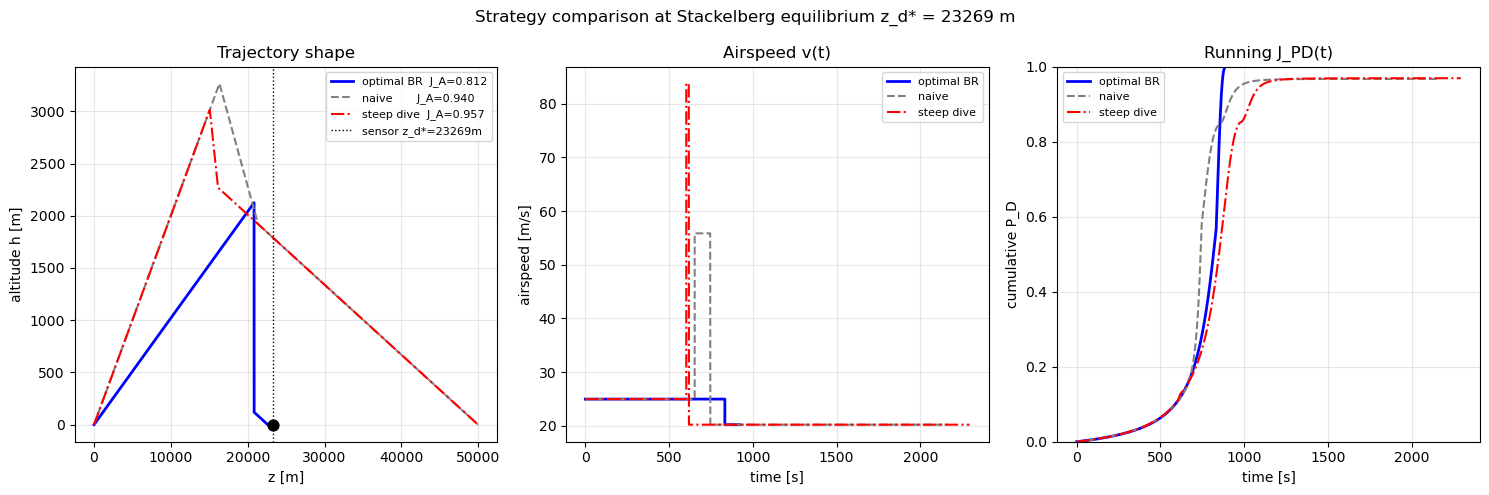

In [ ]:
traj_naive = result_naive["trajectory"]
traj_steep = result_steep["trajectory"]
traj_opt   = result_br["trajectory"]

arr_naive  = game.vehicle.to_arrays(traj_naive)
arr_steep  = game.vehicle.to_arrays(traj_steep)
arr_opt    = game.vehicle.to_arrays(traj_opt)

rates_naive = game.get_individual_pod_arrays(traj_naive, z_d=z_d_eq)
rates_steep = game.get_individual_pod_arrays(traj_steep, z_d=z_d_eq)
rates_opt   = game.get_individual_pod_arrays(traj_opt,   z_d=z_d_eq)

def running_jpd(arr, rates):
    dt     = np.diff(arr["t"])
    total  = sum(rates[k] for k in rates)
    cumint = np.concatenate([[0],
                np.cumsum(0.5*(total[:-1]+total[1:])*dt)])
    return 1.0 - np.exp(-cumint)

jpd_opt   = running_jpd(arr_opt,   rates_opt)
jpd_naive = running_jpd(arr_naive, rates_naive)
jpd_steep = running_jpd(arr_steep, rates_steep)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle(
    f"Strategy comparison at Stackelberg equilibrium z_d* = {z_d_eq:.0f} m",
    fontsize=12
)

# Trajectory shape
axes[0].plot(arr_opt["z"],   arr_opt["h"],
             color="blue",  linewidth=2,
             label=f"optimal BR  J_A={best_br['J_A']:.3f}")
axes[0].plot(arr_naive["z"], arr_naive["h"],
             color="gray",  linewidth=1.5, linestyle="--",
             label=f"naive       J_A={result_naive['J_A']:.3f}")
axes[0].plot(arr_steep["z"], arr_steep["h"],
             color="red",   linewidth=1.5, linestyle="-.",
             label=f"steep dive  J_A={result_steep['J_A']:.3f}")
axes[0].axvline(z_d_eq, color="black", linestyle=":",
                linewidth=1, label=f"sensor z_d*={z_d_eq:.0f}m")
axes[0].scatter([z_d_eq], [0], color="black", zorder=5, s=60)
axes[0].set_xlabel("z [m]")
axes[0].set_ylabel("altitude h [m]")
axes[0].set_title("Trajectory shape")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Airspeed
axes[1].plot(arr_opt["t"],   arr_opt["v"],
             color="blue",  linewidth=2,   label="optimal BR")
axes[1].plot(arr_naive["t"], arr_naive["v"],
             color="gray",  linewidth=1.5, linestyle="--", label="naive")
axes[1].plot(arr_steep["t"], arr_steep["v"],
             color="red",   linewidth=1.5, linestyle="-.", label="steep dive")
axes[1].set_xlabel("time [s]")
axes[1].set_ylabel("airspeed [m/s]")
axes[1].set_title("Airspeed v(t)")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

# Running J_PD
axes[2].plot(arr_opt["t"],   jpd_opt,
             color="blue",  linewidth=2,   label="optimal BR")
axes[2].plot(arr_naive["t"], jpd_naive,
             color="gray",  linewidth=1.5, linestyle="--", label="naive")
axes[2].plot(arr_steep["t"], jpd_steep,
             color="red",   linewidth=1.5, linestyle="-.", label="steep dive")
axes[2].set_xlabel("time [s]")
axes[2].set_ylabel("cumulative P_D")
axes[2].set_title("Running J_PD(t)")
axes[2].set_ylim([0, 1])
axes[2].legend(fontsize=8)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Section 6 — Sensitivity Analysis

How does the Stackelberg equilibrium change when we vary
the attacker's and defender's weighting parameters?

**Attacker sensitivity:** vary α₁/α₂ — how much does the attacker
weight detection probability vs flight time?

**Defender sensitivity:** vary β₁/β₂ — how much does the defender
weight detection probability vs spatial coverage?

In [ ]:
# # Vary alpha_1 (detection weight) from 0.1 to 0.9
# # alpha_2 = 1 - alpha_1 (weights sum to 1)

# alpha_vals = np.linspace(0.1, 0.9, 9)
# z_d_star_alpha = []
# J_A_star_alpha = []
# gamma_star_alpha = []

# print("Attacker weight sensitivity (varying α₁):\n")
# print(f"{'α₁':>6} {'α₂':>6} {'z_d*':>8} {'J_A*':>8} {'γ* (deg)':>10}")
# print("-" * 45)

# for a1 in alpha_vals:
#     a2 = 1.0 - a1
#     game_a = Game(
#         attacker_weights = AttackerWeights(alpha_1=a1, alpha_2=a2),
#         acoustic_params  = AcousticParams(kappa=kappa_ac_cal),
#         doppler_params   = DopplerParams( kappa=kappa_dopp_cal),
#         rcs_params       = RCSParams(     kappa=kappa_rcs_cal),
#         camera_params    = CameraParams(  kappa=kappa_cam_cal),
#     )
#     se = game_a.defender_best_response(n_grid=20, verbose=False)
#     br_a = se["best"]["attacker_response"]
#     z_d_star_alpha.append(se["z_d_star"])
#     J_A_star_alpha.append(br_a["J_A"])
#     gamma_star_alpha.append(np.degrees(br_a["gamma"]))
#     print(f"{a1:>6.2f} {a2:>6.2f} {se['z_d_star']:>8.0f} "
#           f"{br_a['J_A']:>8.4f} {np.degrees(br_a['gamma']):>10.2f}")

# fig, axes = plt.subplots(1, 3, figsize=(14, 4))
# fig.suptitle("Attacker weight sensitivity: varying α₁ (detection weight)", fontsize=12)

# axes[0].plot(alpha_vals, z_d_star_alpha, color="blue", linewidth=2, marker="o")
# axes[0].set_xlabel("α₁ (detection weight)")
# axes[0].set_ylabel("Optimal sensor placement z_d* [m]")
# axes[0].set_title("z_d* vs α₁")
# axes[0].grid(True, alpha=0.3)

# axes[1].plot(alpha_vals, J_A_star_alpha, color="orange", linewidth=2, marker="o")
# axes[1].set_xlabel("α₁ (detection weight)")
# axes[1].set_ylabel("J_A at equilibrium")
# axes[1].set_title("Attacker cost J_A* vs α₁")
# axes[1].grid(True, alpha=0.3)

# axes[2].plot(alpha_vals, gamma_star_alpha, color="purple", linewidth=2, marker="o")
# axes[2].axhline(np.degrees(game.vehicle.gamma_star), color="gray",
#                 linestyle="--", label=f"γ*={np.degrees(game.vehicle.gamma_star):.1f}°")
# axes[2].set_xlabel("α₁ (detection weight)")
# axes[2].set_ylabel("Optimal glide angle γ [deg]")
# axes[2].set_title("Optimal γ vs α₁")
# axes[2].legend(fontsize=8)
# axes[2].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [ ]:
# # Vary beta_1 (detection weight) from 0.1 to 0.9
# # beta_2 = 1 - beta_1

# beta_vals = np.linspace(0.1, 0.9, 9)
# z_d_star_beta = []
# J_D_star_beta = []

# print("Defender weight sensitivity (varying β₁):\n")
# print(f"{'β₁':>6} {'β₂':>6} {'z_d*':>8} {'J_D*':>8}")
# print("-" * 35)

# for b1 in beta_vals:
#     b2 = 1.0 - b1
#     game_b = Game(
#         defender_weights = DefenderWeights(beta_1=b1, beta_2=b2),
#         acoustic_params  = AcousticParams(kappa=kappa_ac_cal),
#         doppler_params   = DopplerParams( kappa=kappa_dopp_cal),
#         rcs_params       = RCSParams(     kappa=kappa_rcs_cal),
#         camera_params    = CameraParams(  kappa=kappa_cam_cal),
#     )
#     se = game_b.defender_best_response(n_grid=20, verbose=False)
#     z_d_star_beta.append(se["z_d_star"])
#     J_D_star_beta.append(se["J_D_star"])
#     print(f"{b1:>6.2f} {b2:>6.2f} {se['z_d_star']:>8.0f} "
#           f"{se['J_D_star']:>8.4f}")

# fig, axes = plt.subplots(1, 2, figsize=(10, 4))
# fig.suptitle("Defender weight sensitivity: varying β₁ (detection weight)", fontsize=12)

# axes[0].plot(beta_vals, z_d_star_beta, color="blue", linewidth=2, marker="o")
# axes[0].set_xlabel("β₁ (detection weight)")
# axes[0].set_ylabel("Optimal sensor placement z_d* [m]")
# axes[0].set_title("z_d* vs β₁")
# axes[0].grid(True, alpha=0.3)

# axes[1].plot(beta_vals, J_D_star_beta, color="green", linewidth=2, marker="o")
# axes[1].set_xlabel("β₁ (detection weight)")
# axes[1].set_ylabel("J_D at equilibrium")
# axes[1].set_title("Defender utility J_D* vs β₁")
# axes[1].grid(True, alpha=0.3)

# plt.tight_layout()
# plt.show()

In [ ]:
print("=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)

print(f"\n1. Sensor calibration (target rate: {target:.0e} at reference point)")
print(f"   κ_acoustic = {kappa_ac_cal:.4e}")
print(f"   κ_doppler  = {kappa_dopp_cal:.4e}")
print(f"   κ_rcs      = {kappa_rcs_cal:.4e}")
print(f"   κ_camera   = {kappa_cam_cal:.4e}")

print(f"\n2. Stackelberg equilibrium (α₁={game.aw.alpha_1}, β₁={game.dw.beta_1})")
print(f"   z_d*   = {stackelberg['z_d_star']:.0f} m")
print(f"   J_D*   = {stackelberg['J_D_star']:.4f}")
print(f"   J_A*   = {best_br['J_A']:.4f}")
print(f"   J_PD*  = {best_br['J_PD']:.4f}")
print(f"   h_sw*  = {best_br['h_sw']:.1f} m")
print(f"   γ*     = {np.degrees(best_br['gamma']):.2f} deg")

print(f"\n3. Value of strategic play (at z_d* = {z_d_eq:.0f} m)")
print(f"   Optimal BR J_A  = {best_br['J_A']:.4f}")
print(f"   Naive J_A       = {result_naive['J_A']:.4f}")
print(f"   Steep dive J_A  = {result_steep['J_A']:.4f}")
print(f"   Reduction vs naive:      "
      f"{result_naive['J_A'] - best_br['J_A']:.4f} "
      f"({100*(result_naive['J_A']-best_br['J_A'])/result_naive['J_A']:.1f}%)")
print(f"   Reduction vs steep dive: "
      f"{result_steep['J_A'] - best_br['J_A']:.4f} "
      f"({100*(result_steep['J_A']-best_br['J_A'])/result_steep['J_A']:.1f}%)")

# print(f"\n4. Sensitivity range")
# print(f"   z_d* range over α₁: "
#       f"{min(z_d_star_alpha):.0f} – {max(z_d_star_alpha):.0f} m")
# print(f"   z_d* range over β₁: "
#       f"{min(z_d_star_beta):.0f} – {max(z_d_star_beta):.0f} m")
# print("=" * 60)

RESULTS SUMMARY


NameError: name 'target' is not defined